In [11]:
import torch
import numpy as np
import os
import sys

sys.path.append("../src")
from train.ElmanRNN import *
import hidden_weights.HiddenWeightHelpers as hw  # plots, stats, norms, etc

In [12]:
def mix_ratio_tag(a: float) -> str:
    """0.90 -> 'sym0p90', 1.0 -> 'sym1p00'"""
    pct = int(round(a * 100))
    major = pct // 100
    minor = pct % 100
    return f"sym{major}p{minor:02d}"

In [13]:
H = HIDDEN_N = 100

## PyTorch Random Weights


=== Vanilla PyTorch random, seed=0 ===
[vanilla] empirical var(Whh) ≈ 0.003334


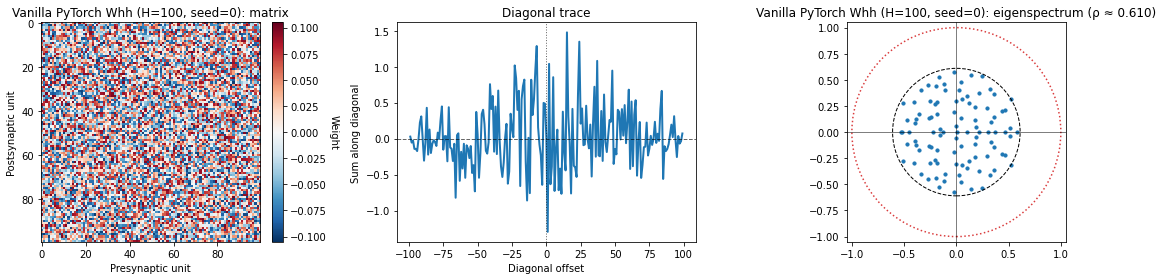

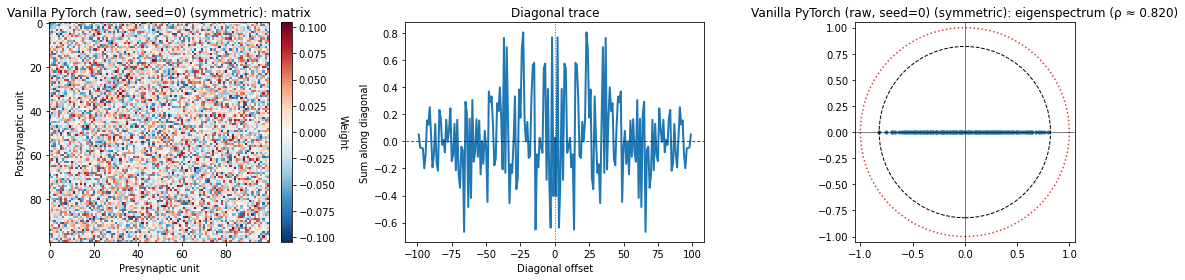

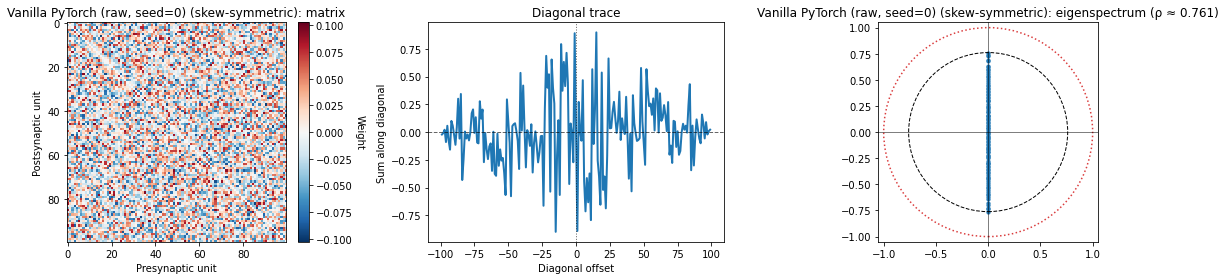

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed000/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed000/Whh.json

=== Vanilla PyTorch random, seed=1 ===
[vanilla] empirical var(Whh) ≈ 0.003324


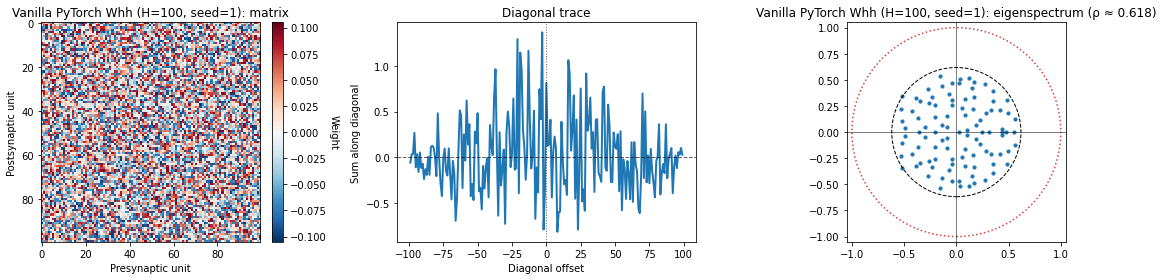

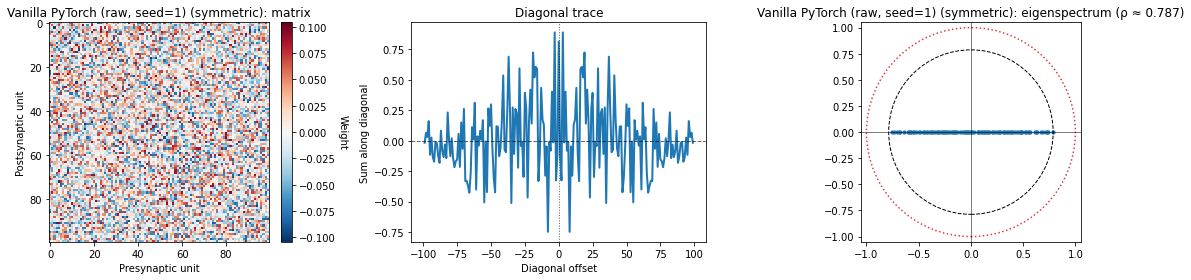

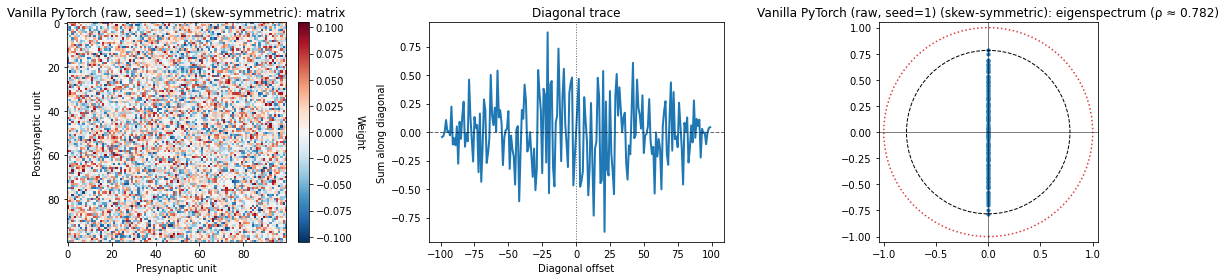

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed001/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed001/Whh.json

=== Vanilla PyTorch random, seed=2 ===
[vanilla] empirical var(Whh) ≈ 0.003305


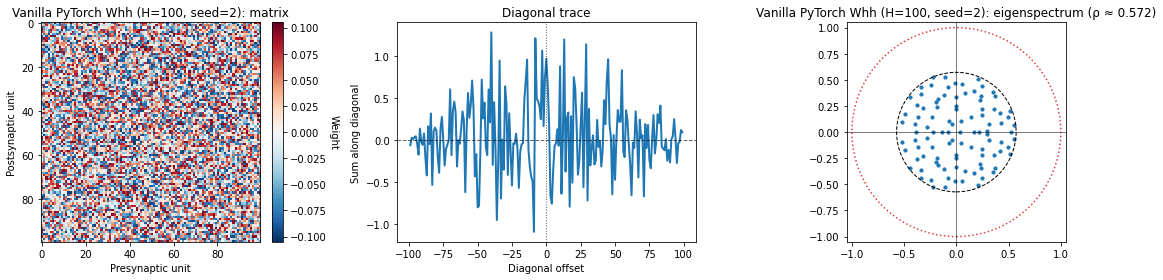

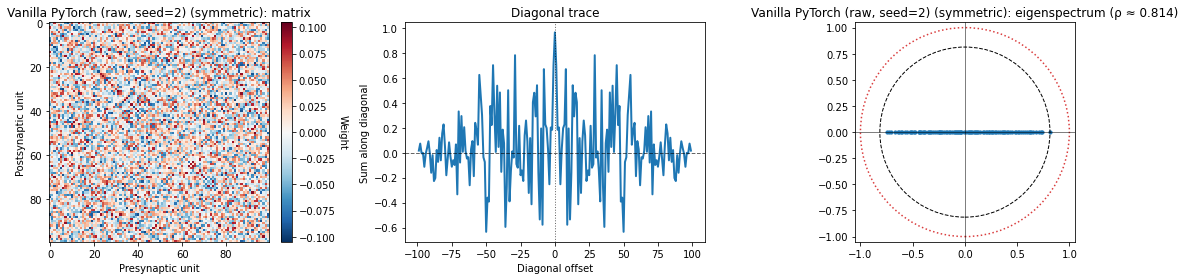

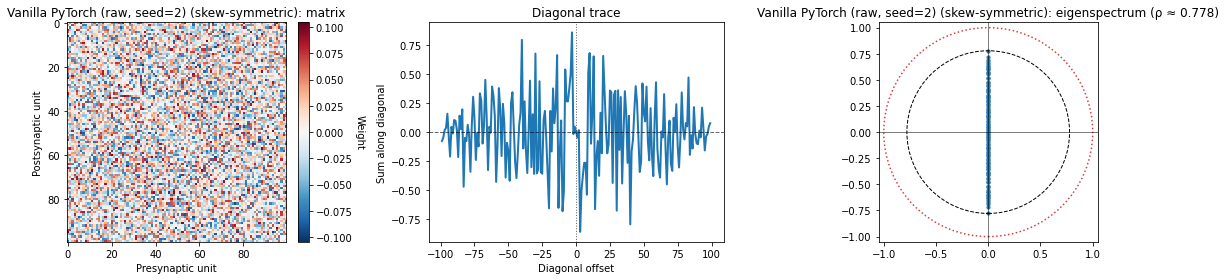

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed002/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed002/Whh.json

=== Vanilla PyTorch random, seed=3 ===
[vanilla] empirical var(Whh) ≈ 0.003362


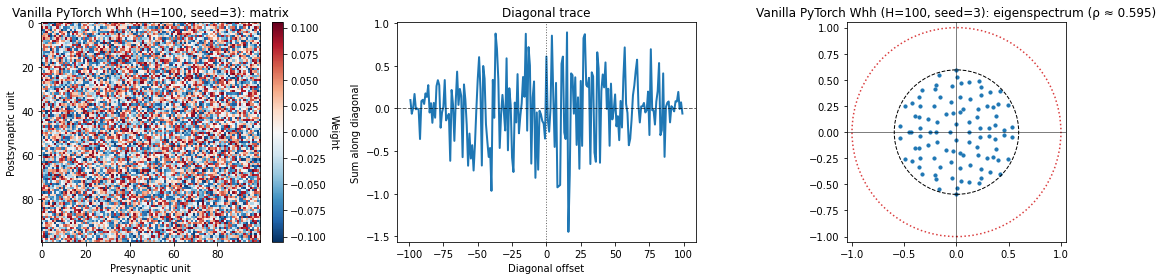

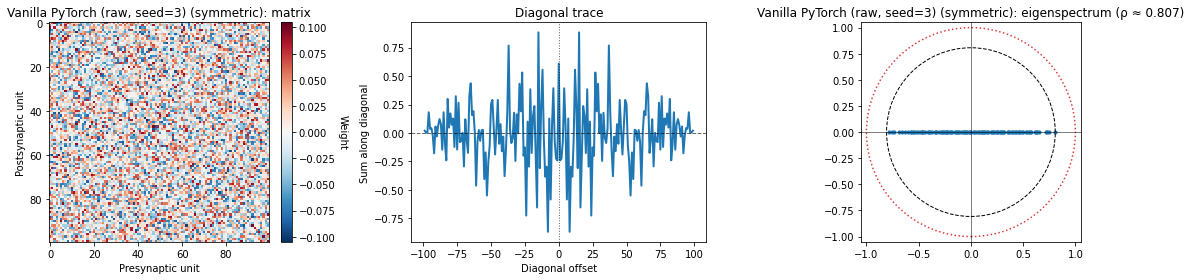

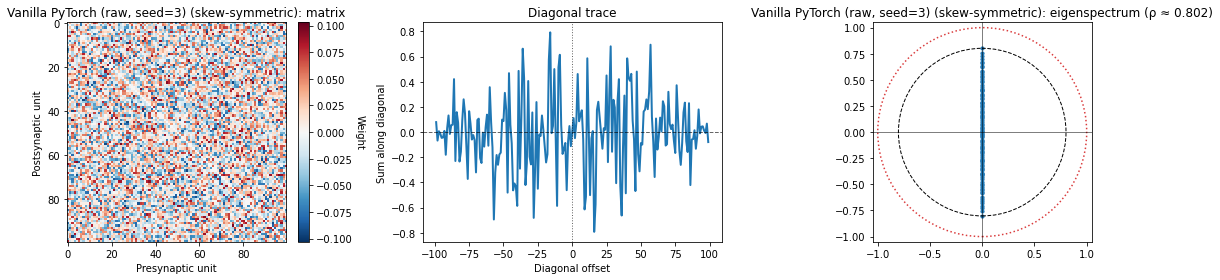

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed003/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed003/Whh.json

=== Vanilla PyTorch random, seed=4 ===
[vanilla] empirical var(Whh) ≈ 0.003357


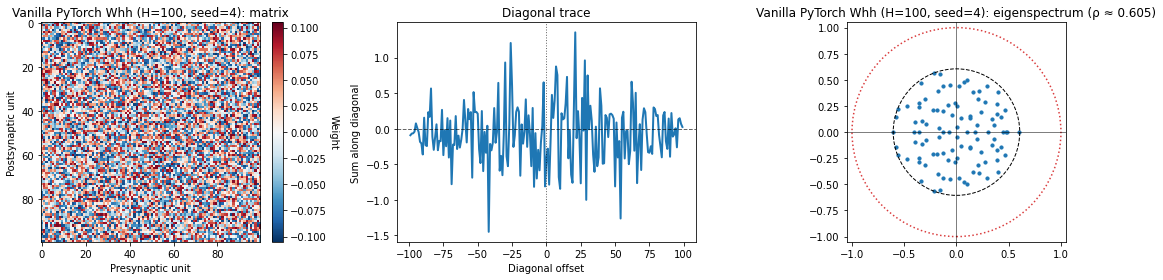

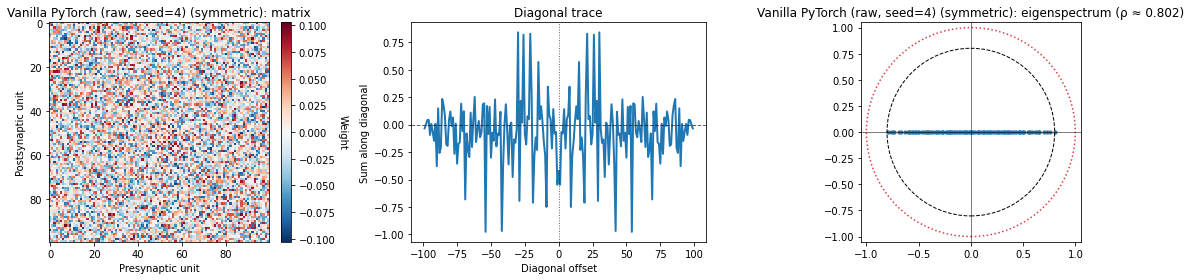

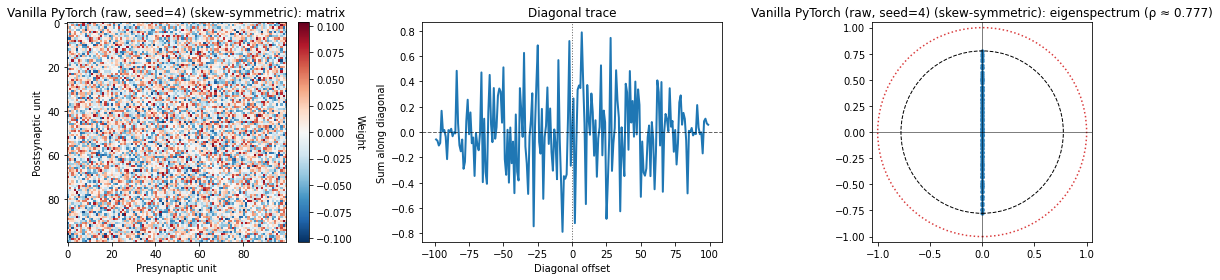

[vanilla] circulant? False (tol=1e-7)
Saved: ../data/hidden_weight_inits/dense/random_pytorch/seed004/Whh.npy and ../data/hidden_weight_inits/dense/random_pytorch/seed004/Whh.json


In [15]:
# ------------------------------------------------
# Vanilla PyTorch random baseline (dense + circulant)
# ------------------------------------------------

seeds = [0, 1, 2, 3, 4]

dense_root = "../data/hidden_weight_inits/dense/random_pytorch"

for seed in seeds:
    print(f"\n=== Vanilla PyTorch random, seed={seed} ===")
    torch.manual_seed(seed)

    # Build model exactly as in training setup
    model = ElmanRNN(
        input_dim=H,
        hidden_dim=H,
        output_dim=H,
        rnn_act="tanh",
    )

    # Extract the dense hidden weight (PyTorch's default init)
    W_dense = model.rnn.weight_hh_l0.detach().cpu().numpy().astype(np.float32)
    emp_var = float(W_dense.var())
    print(f"[vanilla] empirical var(Whh) ≈ {emp_var:.6f}")

    # Plots
    hw.plot_weight_all(W_dense, title=f"Vanilla PyTorch Whh (H={H}, seed={seed})")
    hw.plot_sym_asym(W_dense, base_title=f"Vanilla PyTorch (raw, seed={seed})")

    # Check circulant-ness (it should be False for a generic random matrix)
    ok = hw.is_circulant(W_dense, tol=1e-7)
    print(f"[vanilla] circulant? {ok} (tol=1e-7)")

    # ---------- Save dense version ----------
    save_dir_dense = os.path.join(dense_root, f"seed{seed:03d}")
    fname_dense = "Whh"
    meta_dense = {
        "backend": "dense",
        "family": "vanilla_pytorch",
        "hidden_n": int(H),
        "seed": int(seed),
        "norm": "raw",  # Frobenius normalization happens in Main_clean.py
        "source": "nn.RNN.weight_hh_l0_default_init",
    }
    hw.save_matrix(W_dense, save_dir_dense, fname_dense, meta=meta_dense)